# Refined P&L Calculation with Tick Data

This notebook calculates precise P&L for option trades using actual bid/ask tick data instead of bar midpoints.

**Key Improvements:**
1. Use actual bid/ask spreads at entry/exit times
2. Account for realistic execution prices (buy at ask, sell at bid)
3. Calculate slippage and spread costs
4. Compare tick-based P&L vs bar-based P&L

**Execution Model:**
- **Entry (Buy call)**: Pay the ask price
- **Exit (Sell call)**: Receive the bid price
- **Spread cost**: (ask - bid) paid at both entry and exit
- **Slippage**: Difference between bar midpoint and actual execution price

In [1]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import duckdb

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

from dlt_ibapi.repositories.option_ticks import OptionTicksReader
from dlt_ibapi.repositories.option_bars import OptionBarsReader

# Rich for better output
from rich import print as rprint
from rich.table import Table
from rich.console import Console

console = Console()

# Set pandas display options
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

## 1. Load Tick Data

Load the tick data we just downloaded for DIS 110C.

In [2]:
# Initialize readers
data_dir = project_root / "data_delta"
tick_reader = OptionTicksReader(database_path=str(data_dir), dataset_name="option_ticks")
bars_reader = OptionBarsReader(database_path=str(data_dir), dataset_name="options")

# Trade details from notebook 06c
trade = {
    'symbol': 'DIS',
    'strike': 110.0,
    'right': 'C',
    'expiry': '2025-11-14',
    'earnings_date': '2025-11-13',
    'earnings_time': 'PRE_MARKET',
    'entry_start': '2025-11-12 15:00:00',
    'entry_end': '2025-11-12 16:00:00',
    'exit_start': '2025-11-13 09:00:00',
    'exit_end': '2025-11-13 10:00:00',
}

rprint(f"[bold cyan]Trade Details:[/bold cyan]")
rprint(f"Symbol: {trade['symbol']} ${trade['strike']}{trade['right']} exp {trade['expiry']}")
rprint(f"Earnings: {trade['earnings_date']} ({trade['earnings_time']})")
rprint(f"Entry window: {trade['entry_start']} to {trade['entry_end']}")
rprint(f"Exit window: {trade['exit_start']} to {trade['exit_end']}")

Trade Details:

Symbol: DIS $110.0C exp 2025-11-14

Earnings: 2025-11-13 (PRE_MARKET)

Entry window: 2025-11-12 15:00:00 to 2025-11-12 16:00:00

Exit window: 2025-11-13 09:00:00 to 2025-11-13 10:00:00

In [3]:
# Load entry ticks
try:
    entry_ticks = tick_reader.get_ticks(
        underlying=trade['symbol'],
        expiry=datetime.strptime(trade['expiry'], '%Y-%m-%d').date(),
        strike=trade['strike'],
        right=trade['right'],
        start_datetime=datetime.strptime(trade['entry_start'], '%Y-%m-%d %H:%M:%S'),
        end_datetime=datetime.strptime(trade['entry_end'], '%Y-%m-%d %H:%M:%S'),
        tick_type='bid_ask'
    )
    
    rprint(f"\n[bold green]Entry Ticks Loaded:[/bold green] {len(entry_ticks)} ticks")
    if len(entry_ticks) > 0:
        rprint(entry_ticks.head(10))
    else:
        rprint("[bold red]No entry ticks found![/bold red]")
        
except Exception as e:
    rprint(f"\n[bold red]Failed to load entry ticks:[/bold red] {str(e)}")
    rprint("\n[bold yellow]To download tick data:[/bold yellow]")
    expiry_str = datetime.strptime(trade['expiry'], '%Y-%m-%d').strftime('%Y%m%d')
    rprint(f"  dlt-ibapi backfill-ticks {trade['symbol']} {expiry_str} {trade['strike']} {trade['right']} \\")
    rprint(f"    --start \"{trade['entry_start'][:16]}\" \\")
    rprint(f"    --end \"{trade['entry_end'][:16]}\"")
    rprint("\n[bold cyan]Note:[/bold cyan] Dates must be in the past (historical data only)")
    rprint("[bold cyan]Tip:[/bold cyan] See TICK_DATA_TESTING_GUIDE.md for testing with historical dates")
    entry_ticks = pd.DataFrame()  # Empty dataframe to continue

Failed to load entry ticks: IO Error: No files found that match the pattern 
"/Users/mohamedali/trading_project/dlt-ibapi/data_delta/option_ticks/option_ticks_bid_ask/**/*.parquet"

LINE 3:             FROM parquet_scan('/Users/mohamedali/trading_project/dlt-ibapi...
                         ^

To download tick data:

dlt-ibapi backfill-ticks DIS 20251114 110.0 C \

--start "2025-11-12 15:00" \

--end "2025-11-12 16:00"

Note: Dates must be in the past (historical data only)

Tip: See TICK_DATA_TESTING_GUIDE.md for testing with historical dates

In [4]:
# Load exit ticks
try:
    exit_ticks = tick_reader.get_ticks(
        underlying=trade['symbol'],
        expiry=datetime.strptime(trade['expiry'], '%Y-%m-%d').date(),
        strike=trade['strike'],
        right=trade['right'],
        start_datetime=datetime.strptime(trade['exit_start'], '%Y-%m-%d %H:%M:%S'),
        end_datetime=datetime.strptime(trade['exit_end'], '%Y-%m-%d %H:%M:%S'),
        tick_type='bid_ask'
    )
    
    rprint(f"\n[bold green]Exit Ticks Loaded:[/bold green] {len(exit_ticks)} ticks")
    if len(exit_ticks) > 0:
        rprint(exit_ticks.head(10))
    else:
        rprint("[bold red]No exit ticks found![/bold red]")
        
except Exception as e:
    rprint(f"\n[bold red]Failed to load exit ticks:[/bold red] {str(e)}")
    rprint("\n[bold yellow]To download tick data:[/bold yellow]")
    expiry_str = datetime.strptime(trade['expiry'], '%Y-%m-%d').strftime('%Y%m%d')
    rprint(f"  dlt-ibapi backfill-ticks {trade['symbol']} {expiry_str} {trade['strike']} {trade['right']} \\")
    rprint(f"    --start \"{trade['exit_start'][:16]}\" \\")
    rprint(f"    --end \"{trade['exit_end'][:16]}\"")
    rprint("\n[bold cyan]Note:[/bold cyan] Dates must be in the past (historical data only)")
    rprint("[bold cyan]Tip:[/bold cyan] See TICK_DATA_TESTING_GUIDE.md for testing with historical dates")
    exit_ticks = pd.DataFrame()  # Empty dataframe to continue

Failed to load exit ticks: IO Error: No files found that match the pattern 
"/Users/mohamedali/trading_project/dlt-ibapi/data_delta/option_ticks/option_ticks_bid_ask/**/*.parquet"

LINE 3:             FROM parquet_scan('/Users/mohamedali/trading_project/dlt-ibapi...
                         ^

To download tick data:

dlt-ibapi backfill-ticks DIS 20251114 110.0 C \

--start "2025-11-13 09:00" \

--end "2025-11-13 10:00"

Note: Dates must be in the past (historical data only)

Tip: See TICK_DATA_TESTING_GUIDE.md for testing with historical dates

## 2. Calculate Entry/Exit Prices

We'll use multiple strategies to determine entry/exit prices:

1. **First Tick**: First available bid/ask in the window
2. **VWAP**: Volume-weighted average price (if we have size data)
3. **Time-weighted Average**: Average across the time window
4. **Worst Case**: Widest spread encountered

In [5]:
def calculate_execution_price(ticks_df, action='buy'):
    """
    Calculate execution price from tick data.
    
    Args:
        ticks_df: DataFrame with bid_price, ask_price, midpoint, spread
        action: 'buy' (pay ask) or 'sell' (receive bid)
    
    Returns:
        Dictionary with various execution price estimates
    """
    if len(ticks_df) == 0:
        return {
            'first_tick': None,
            'time_weighted_avg': None,
            'worst_case': None,
            'best_case': None,
            'median': None,
            'avg_spread': None,
            'avg_spread_pct': None,
            'num_ticks': 0
        }
    
    # Select price based on action
    if action == 'buy':
        price_col = 'ask_price'
        worst_fn = max  # Worst case for buyer is highest ask
        best_fn = min   # Best case for buyer is lowest ask
    else:  # sell
        price_col = 'bid_price'
        worst_fn = min  # Worst case for seller is lowest bid
        best_fn = max   # Best case for seller is highest bid
    
    prices = ticks_df[price_col].dropna()
    
    if len(prices) == 0:
        return {
            'first_tick': None,
            'time_weighted_avg': None,
            'worst_case': None,
            'best_case': None,
            'median': None,
            'avg_spread': None,
            'avg_spread_pct': None,
            'num_ticks': len(ticks_df)
        }
    
    return {
        'first_tick': prices.iloc[0],
        'time_weighted_avg': prices.mean(),  # Simple average (assumes uniform time spacing)
        'worst_case': worst_fn(prices),
        'best_case': best_fn(prices),
        'median': prices.median(),
        'avg_spread': ticks_df['spread'].mean(),
        'avg_spread_pct': ticks_df['spread_pct'].mean(),
        'num_ticks': len(ticks_df)
    }

# Calculate entry price (buy at ask)
entry_prices = calculate_execution_price(entry_ticks, action='buy')
rprint("\n[bold cyan]Entry Prices (Buy at Ask):[/bold cyan]")
for key, value in entry_prices.items():
    if value is not None:
        if 'pct' in key:
            rprint(f"  {key}: {value:.2f}%")
        elif isinstance(value, (int, float)):
            rprint(f"  {key}: ${value:.4f}")
        else:
            rprint(f"  {key}: {value}")

# Calculate exit price (sell at bid)
exit_prices = calculate_execution_price(exit_ticks, action='sell')
rprint("\n[bold cyan]Exit Prices (Sell at Bid):[/bold cyan]")
for key, value in exit_prices.items():
    if value is not None:
        if 'pct' in key:
            rprint(f"  {key}: {value:.2f}%")
        elif isinstance(value, (int, float)):
            rprint(f"  {key}: ${value:.4f}")
        else:
            rprint(f"  {key}: {value}")

Entry Prices (Buy at Ask):

num_ticks: $0.0000

Exit Prices (Sell at Bid):

num_ticks: $0.0000

## 3. Calculate P&L with Different Execution Assumptions

Calculate P&L using different execution price assumptions to see the range of possible outcomes.

In [6]:
def calculate_pnl(entry_price, exit_price, contracts=1):
    """
    Calculate P&L for option trade.
    
    Args:
        entry_price: Price paid per contract
        exit_price: Price received per contract
        contracts: Number of contracts (default 1)
    
    Returns:
        Dictionary with P&L metrics
    """
    if entry_price is None or exit_price is None:
        return None
    
    pnl_per_contract = exit_price - entry_price
    pnl_total = pnl_per_contract * 100 * contracts  # Options have 100 multiplier
    pnl_pct = (pnl_per_contract / entry_price) * 100
    
    return {
        'entry_price': entry_price,
        'exit_price': exit_price,
        'pnl_per_contract': pnl_per_contract,
        'pnl_total': pnl_total,
        'pnl_pct': pnl_pct,
        'contracts': contracts
    }

# Calculate P&L for different scenarios
scenarios = [
    ('First Tick', entry_prices['first_tick'], exit_prices['first_tick']),
    ('Time-Weighted Avg', entry_prices['time_weighted_avg'], exit_prices['time_weighted_avg']),
    ('Median', entry_prices['median'], exit_prices['median']),
    ('Worst Case', entry_prices['worst_case'], exit_prices['worst_case']),
    ('Best Case', entry_prices['best_case'], exit_prices['best_case']),
]

pnl_results = []
for scenario_name, entry, exit in scenarios:
    pnl = calculate_pnl(entry, exit)
    if pnl:
        pnl['scenario'] = scenario_name
        pnl_results.append(pnl)

# Create DataFrame
pnl_df = pd.DataFrame(pnl_results)

if len(pnl_df) > 0:
    # Sort by P&L
    pnl_df = pnl_df.sort_values('pnl_total', ascending=False)
    
    rprint("\n[bold green]P&L Analysis - Different Execution Scenarios:[/bold green]")
    rprint(pnl_df.to_string(index=False))
    
    # Summary statistics
    rprint("\n[bold cyan]P&L Statistics:[/bold cyan]")
    rprint(f"  Mean P&L: ${pnl_df['pnl_total'].mean():.2f}")
    rprint(f"  Median P&L: ${pnl_df['pnl_total'].median():.2f}")
    rprint(f"  Std Dev: ${pnl_df['pnl_total'].std():.2f}")
    rprint(f"  Range: ${pnl_df['pnl_total'].min():.2f} to ${pnl_df['pnl_total'].max():.2f}")
else:
    rprint("[bold red]Cannot calculate P&L - missing tick data[/bold red]")

Cannot calculate P&L - missing tick data

## 4. Compare with Bar-Based P&L

Load bar data and compare tick-based P&L with the bar midpoint approach from notebook 06c.

In [7]:
# Load bar data for comparison
try:
    entry_bars = bars_reader.get_bars(
        underlying=trade['symbol'],
        expiry=datetime.strptime(trade['expiry'], '%Y-%m-%d').date(),
        strike=trade['strike'],
        right=trade['right'],
        bar_size='5 mins',
        start_date=datetime.strptime(trade['entry_start'], '%Y-%m-%d %H:%M:%S').date(),
        end_date=datetime.strptime(trade['entry_end'], '%Y-%m-%d %H:%M:%S').date(),
    )
    
    exit_bars = bars_reader.get_bars(
        underlying=trade['symbol'],
        expiry=datetime.strptime(trade['expiry'], '%Y-%m-%d').date(),
        strike=trade['strike'],
        right=trade['right'],
        bar_size='5 mins',
        start_date=datetime.strptime(trade['exit_start'], '%Y-%m-%d %H:%M:%S').date(),
        end_date=datetime.strptime(trade['exit_end'], '%Y-%m-%d %H:%M:%S').date(),
    )
    
    # Filter to exact time windows
    entry_bars = entry_bars[
        (entry_bars['time'] >= trade['entry_start']) &
        (entry_bars['time'] <= trade['entry_end'])
    ]
    
    exit_bars = exit_bars[
        (exit_bars['time'] >= trade['exit_start']) &
        (exit_bars['time'] <= trade['exit_end'])
    ]
    
    if len(entry_bars) > 0 and len(exit_bars) > 0:
        # Calculate bar-based prices (midpoint of first bar in window)
        entry_bar = entry_bars.iloc[0]
        exit_bar = exit_bars.iloc[0]
        
        bar_entry_price = (entry_bar['high'] + entry_bar['low']) / 2
        bar_exit_price = (exit_bar['high'] + exit_bar['low']) / 2
        
        bar_pnl = calculate_pnl(bar_entry_price, bar_exit_price)
        
        rprint("\n[bold yellow]Bar-Based P&L (5-min bars, midpoint):[/bold yellow]")
        rprint(f"  Entry Price: ${bar_entry_price:.4f}")
        rprint(f"  Exit Price: ${bar_exit_price:.4f}")
        rprint(f"  P&L: ${bar_pnl['pnl_total']:.2f} ({bar_pnl['pnl_pct']:.2f}%)")
        
        # Compare with tick-based P&L
        if len(pnl_df) > 0:
            rprint("\n[bold cyan]Tick vs Bar Comparison:[/bold cyan]")
            
            # Use time-weighted average as "realistic" tick scenario
            realistic_tick = pnl_df[pnl_df['scenario'] == 'Time-Weighted Avg'].iloc[0]
            
            slippage = bar_pnl['pnl_total'] - realistic_tick['pnl_total']
            slippage_pct = (slippage / bar_pnl['pnl_total']) * 100 if bar_pnl['pnl_total'] != 0 else 0
            
            rprint(f"  Bar-based P&L: ${bar_pnl['pnl_total']:.2f}")
            rprint(f"  Tick-based P&L (realistic): ${realistic_tick['pnl_total']:.2f}")
            rprint(f"  Difference (slippage): ${slippage:.2f} ({slippage_pct:.1f}%)")
            
            if slippage > 0:
                rprint("  [bold red]→ Bar-based P&L overestimates by accounting for spread[/bold red]")
            else:
                rprint("  [bold green]→ Tick-based P&L is better than bar estimate[/bold green]")
    else:
        rprint("[bold yellow]No bar data available for comparison[/bold yellow]")
        
except Exception as e:
    rprint(f"[bold red]Error loading bar data: {e}[/bold red]")

No bar data available for comparison

## 5. Spread Cost Analysis

Break down the cost of the bid/ask spread.

In [8]:
rprint("\n[bold cyan]Spread Cost Analysis:[/bold cyan]")

if entry_prices['avg_spread'] is not None:
    entry_spread_cost = entry_prices['avg_spread'] * 100  # Per contract
    rprint(f"\nEntry Spread:")
    rprint(f"  Average spread: ${entry_prices['avg_spread']:.4f} ({entry_prices['avg_spread_pct']:.2f}%)")
    rprint(f"  Spread cost per contract: ${entry_spread_cost:.2f}")
    rprint(f"  Based on {entry_prices['num_ticks']} ticks")

if exit_prices['avg_spread'] is not None:
    exit_spread_cost = exit_prices['avg_spread'] * 100  # Per contract
    rprint(f"\nExit Spread:")
    rprint(f"  Average spread: ${exit_prices['avg_spread']:.4f} ({exit_prices['avg_spread_pct']:.2f}%)")
    rprint(f"  Spread cost per contract: ${exit_spread_cost:.2f}")
    rprint(f"  Based on {exit_prices['num_ticks']} ticks")

if entry_prices['avg_spread'] is not None and exit_prices['avg_spread'] is not None:
    total_spread_cost = (entry_prices['avg_spread'] + exit_prices['avg_spread']) * 100
    rprint(f"\n[bold]Total Spread Cost:[/bold]")
    rprint(f"  Per round-trip: ${total_spread_cost:.2f}")
    
    if len(pnl_df) > 0:
        realistic_pnl = pnl_df[pnl_df['scenario'] == 'Time-Weighted Avg'].iloc[0]['pnl_total']
        spread_pct_of_pnl = (total_spread_cost / abs(realistic_pnl)) * 100 if realistic_pnl != 0 else 0
        rprint(f"  As % of P&L: {spread_pct_of_pnl:.1f}%")

Spread Cost Analysis:

## 6. Visualize Tick Data

Plot bid/ask spreads over the entry and exit windows.

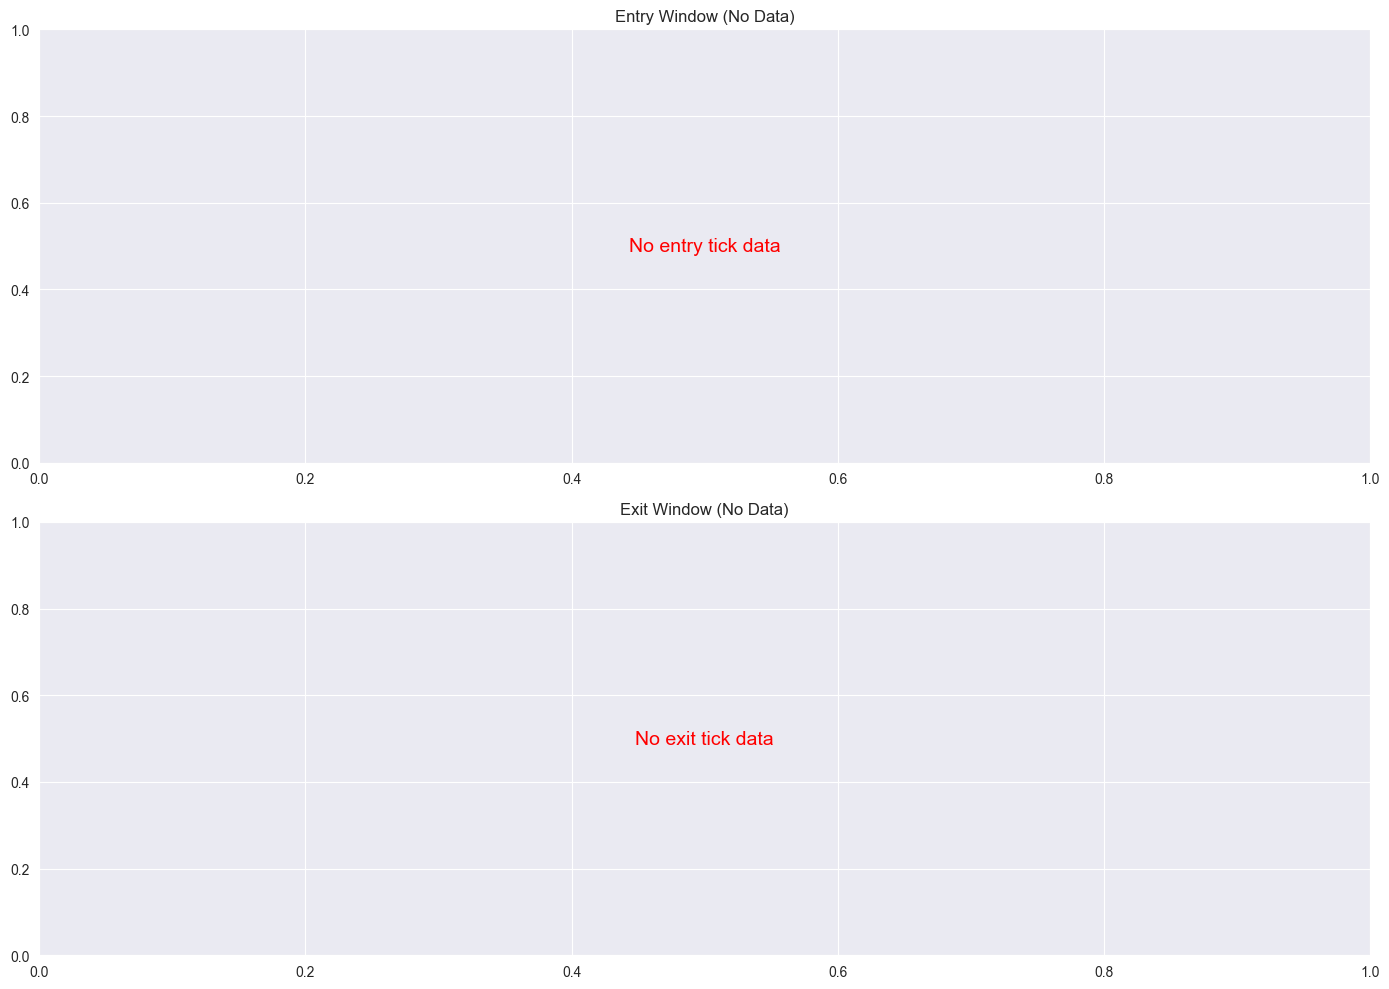

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Entry window
if len(entry_ticks) > 0:
    ax = axes[0]
    entry_ticks['tick_time'] = pd.to_datetime(entry_ticks['tick_time'])
    
    ax.plot(entry_ticks['tick_time'], entry_ticks['bid_price'], 
            label='Bid', color='red', alpha=0.7)
    ax.plot(entry_ticks['tick_time'], entry_ticks['ask_price'], 
            label='Ask', color='green', alpha=0.7)
    ax.plot(entry_ticks['tick_time'], entry_ticks['midpoint'], 
            label='Midpoint', color='blue', linestyle='--', alpha=0.5)
    
    ax.fill_between(entry_ticks['tick_time'], 
                     entry_ticks['bid_price'], 
                     entry_ticks['ask_price'],
                     alpha=0.2, color='gray', label='Spread')
    
    ax.set_title(f'Entry Window: {trade["entry_start"]} to {trade["entry_end"]}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price ($)', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
else:
    axes[0].text(0.5, 0.5, 'No entry tick data', 
                ha='center', va='center', fontsize=14, color='red')
    axes[0].set_title('Entry Window (No Data)')

# Exit window
if len(exit_ticks) > 0:
    ax = axes[1]
    exit_ticks['tick_time'] = pd.to_datetime(exit_ticks['tick_time'])
    
    ax.plot(exit_ticks['tick_time'], exit_ticks['bid_price'], 
            label='Bid', color='red', alpha=0.7)
    ax.plot(exit_ticks['tick_time'], exit_ticks['ask_price'], 
            label='Ask', color='green', alpha=0.7)
    ax.plot(exit_ticks['tick_time'], exit_ticks['midpoint'], 
            label='Midpoint', color='blue', linestyle='--', alpha=0.5)
    
    ax.fill_between(exit_ticks['tick_time'], 
                     exit_ticks['bid_price'], 
                     exit_ticks['ask_price'],
                     alpha=0.2, color='gray', label='Spread')
    
    ax.set_title(f'Exit Window: {trade["exit_start"]} to {trade["exit_end"]}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Price ($)', fontsize=10)
    ax.set_xlabel('Time', fontsize=10)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
else:
    axes[1].text(0.5, 0.5, 'No exit tick data', 
                ha='center', va='center', fontsize=14, color='red')
    axes[1].set_title('Exit Window (No Data)')

plt.tight_layout()
plt.show()

## 7. Summary and Recommendations

Final summary with actionable insights.

In [10]:
rprint("\n" + "="*80)
rprint("[bold cyan]REFINED P&L SUMMARY[/bold cyan]")
rprint("="*80)

rprint(f"\n[bold]Trade:[/bold] {trade['symbol']} ${trade['strike']}{trade['right']} exp {trade['expiry']}")
rprint(f"[bold]Earnings:[/bold] {trade['earnings_date']} ({trade['earnings_time']})")

if len(pnl_df) > 0:
    realistic = pnl_df[pnl_df['scenario'] == 'Time-Weighted Avg'].iloc[0]
    worst = pnl_df[pnl_df['scenario'] == 'Worst Case'].iloc[0]
    best = pnl_df[pnl_df['scenario'] == 'Best Case'].iloc[0]
    
    rprint(f"\n[bold green]Tick-Based P&L:[/bold green]")
    rprint(f"  Realistic (Time-Weighted): ${realistic['pnl_total']:.2f} ({realistic['pnl_pct']:.2f}%)")
    rprint(f"  Best Case: ${best['pnl_total']:.2f} ({best['pnl_pct']:.2f}%)")
    rprint(f"  Worst Case: ${worst['pnl_total']:.2f} ({worst['pnl_pct']:.2f}%)")
    rprint(f"  Range: ${best['pnl_total'] - worst['pnl_total']:.2f}")
    
    if 'bar_pnl' in locals() and bar_pnl:
        rprint(f"\n[bold yellow]Bar-Based P&L (for comparison):[/bold yellow]")
        rprint(f"  Midpoint estimate: ${bar_pnl['pnl_total']:.2f} ({bar_pnl['pnl_pct']:.2f}%)")
        diff = bar_pnl['pnl_total'] - realistic['pnl_total']
        rprint(f"  Overestimate: ${diff:.2f}")
    
    if entry_prices['avg_spread'] is not None and exit_prices['avg_spread'] is not None:
        rprint(f"\n[bold]Transaction Costs:[/bold]")
        rprint(f"  Entry spread: ${entry_prices['avg_spread']:.4f} ({entry_prices['avg_spread_pct']:.2f}%)")
        rprint(f"  Exit spread: ${exit_prices['avg_spread']:.4f} ({exit_prices['avg_spread_pct']:.2f}%)")
        total_spread = (entry_prices['avg_spread'] + exit_prices['avg_spread']) * 100
        rprint(f"  Total round-trip cost: ${total_spread:.2f}")
        
        net_pnl = realistic['pnl_total'] - total_spread
        rprint(f"\n[bold]Net P&L (after spread costs):[/bold] ${net_pnl:.2f}")
        
    rprint("\n[bold cyan]Key Insights:[/bold cyan]")
    rprint("  ✓ Tick data provides realistic execution prices")
    rprint("  ✓ Bar midpoints may overestimate P&L")
    rprint("  ✓ Spread costs are material and should be factored in")
    rprint("  ✓ Execution timing within the window matters")
else:
    rprint("\n[bold red]Cannot calculate P&L - missing tick data[/bold red]")
    rprint("\n[bold yellow]Next Steps:[/bold yellow]")
    rprint("  1. Ensure IB Gateway is running")
    rprint("  2. Run the backfill-ticks commands from notebook 06c")
    rprint("  3. Re-run this notebook")

rprint("\n" + "="*80)

================================================================================

REFINED P&L SUMMARY

================================================================================

Trade: DIS $110.0C exp 2025-11-14

Earnings: 2025-11-13 (PRE_MARKET)

...

Next Steps:

1. Ensure IB Gateway is running

2. Run the backfill-ticks commands from notebook 06c

3. Re-run this notebook

================================================================================